# Actividad Extracción de conocimiento en Bases de Datos

## Lab14 - Algoritmo K-Nearest Neighbors (KNN): Arroyo Muñoz Luz Carla


In [1]:
# Cargar las librerías requeridas
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Carga del conjunto de datos

In [2]:
# Cargamos el dataset Wine directamente desde scikit-learn
wine = load_wine(as_frame=True)

In [3]:
# Mostramos la descripción general del dataset
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
# Convertimos el dataset en un DataFrame de pandas
dfWine = wine.frame

In [5]:
# Mostramos los primeros cinco registros
dfWine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Exploración del conjunto de datos

In [6]:
# Consultamos el número de filas y columnas
dfWine.shape

(178, 14)

In [7]:
# Consultamos los nombres de las columnas
dfWine.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [8]:
# Mostramos los nombres originales de las clases
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [9]:
# Revisamos los tipos de datos y valores no nulos
dfWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [10]:
# Obtenemos estadísticas descriptivas de las variables numéricas
dfWine.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## Limpieza y preparación de los datos

In [11]:
# Verificamos si existen valores nulos por columna
dfWine.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [12]:
# Verificamos si existen registros duplicados
print("Registros duplicados:", dfWine.duplicated().sum())

Registros duplicados: 0


In [13]:
# Renombramos la columna objetivo para que sea más fácil de identificar
dfWine.rename(columns={"target": "clase_vino"}, inplace=True)

In [14]:
# Cambiamos los valores numéricos de la variable objetivo por nombres descriptivos
dfWine["clase_vino"] = dfWine["clase_vino"].map({
    0: "class_0",
    1: "class_1",
    2: "class_2"
})

In [15]:
# Mostramos los últimos registros para comprobar los cambios
dfWine.tail()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase_vino
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0,class_2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0,class_2


In [16]:
# Revisamos cuántos registros existen en cada clase
dfWine["clase_vino"].value_counts()

clase_vino
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

## Identificar variables predictoras y variable objetivo

In [17]:
# Variables predictoras: todas las columnas excepto la clase del vino
X = dfWine.drop(columns=["clase_vino"])

In [18]:
print("Variables predictoras:")
print(X.columns)

Variables predictoras:
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In [19]:
# Variable objetivo: clase del vino
y = dfWine["clase_vino"]

In [20]:
print("Variable objetivo:")
print(y.name)

Variable objetivo:
clase_vino


## Dividir los datos en entrenamiento y prueba

- **80 %** para entrenamiento.
- **20 %** para prueba.
- Se utiliza `stratify=y` para conservar la proporción de las clases.

In [21]:
# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [22]:
# Mostramos las dimensiones de cada conjunto
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (142, 13)
X_test: (36, 13)
y_train: (142,)
y_test: (36,)


## Escalado de variables

KNN utiliza distancias para encontrar los vecinos más cercanos. Por esta razón, es necesario estandarizar las variables para evitar que las columnas con valores más grandes tengan mayor influencia.

In [23]:
# Creamos el objeto para estandarizar los datos
scaler = StandardScaler()

In [24]:
# Ajustamos el escalador únicamente con los datos de entrenamiento
# Después transformamos tanto entrenamiento como prueba
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

In [25]:
# Comparamos algunos datos originales con los datos escalados
print("Datos sin escalar:")
display(X_train.head())

print("Datos escalados:")
display(pd.DataFrame(
    X_train_escalado,
    columns=X.columns,
    index=X_train.index
).head())

Datos sin escalar:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0


Datos escalados:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,0.385801,-0.637871,1.776668,-1.224532,0.696430,0.526865,0.732292,-0.169549,-0.415783,-0.167467,0.624378,0.252908,0.467725
30,0.948519,-0.765445,1.253174,0.853284,0.091785,1.172795,1.333181,-0.590457,1.349742,0.305303,1.067155,0.151048,1.815768
26,0.523354,-0.519409,0.954034,-1.046433,-0.445678,0.930572,1.006382,-0.169549,-0.260002,-0.081509,-0.128343,0.893172,1.516203
12,0.973529,-0.555859,0.168793,-1.076116,-0.714409,0.526865,0.816627,-0.590457,0.363125,0.262324,0.890044,0.427526,1.932265
148,0.435820,0.820120,0.056615,0.556453,-0.512860,-0.555068,-1.291756,0.756449,-0.606183,1.474335,-1.766619,-1.435059,-0.297831


## Entrenamiento del modelo KNN

En esta práctica utilizaremos **K = 3**, por lo que el modelo tomará en cuenta a los tres vecinos más cercanos para realizar cada clasificación.

In [26]:
# Creamos el modelo KNN con tres vecinos
modelo = KNeighborsClassifier(n_neighbors=3)

In [27]:
# Entrenamos el modelo con los datos escalados
modelo.fit(X_train_escalado, y_train)

KNeighborsClassifier(n_neighbors=3)

## Realizar predicciones con los datos de prueba

In [28]:
# Realizamos las predicciones
prediccion = modelo.predict(X_test_escalado)

In [29]:
# Mostramos las primeras diez predicciones
print(prediccion[:10])

['class_0' 'class_2' 'class_0' 'class_0' 'class_1' 'class_0' 'class_0'
 'class_1' 'class_1' 'class_2']


In [30]:
# Comparamos los valores reales con los valores predichos
comparacion = pd.DataFrame({
    "clase_real": y_test.values,
    "clase_predicha": prediccion
})

comparacion.head(20)

,clase_real,clase_predicha
0,class_0,class_0
1,class_2,class_2
2,class_0,class_0
3,class_1,class_0
4,class_1,class_1
5,class_0,class_0
6,class_0,class_0
7,class_1,class_1
8,class_1,class_1
9,class_2,class_2


## Evaluación del modelo

In [31]:
# Calculamos la exactitud general del modelo
accuracy = accuracy_score(y_test, prediccion)

print(f"Accuracy / exactitud: {accuracy:.4f}")
print(f"Porcentaje de aciertos: {accuracy * 100:.2f}%")

Accuracy / exactitud: 0.9722
Porcentaje de aciertos: 97.22%


### Matriz de confusión

In [32]:
# Calculamos la matriz de confusión
cm = confusion_matrix(
    y_test,
    prediccion,
    labels=modelo.classes_
)

# Convertimos la matriz en un DataFrame para facilitar su lectura
cm_df = pd.DataFrame(
    cm,
    index=modelo.classes_,
    columns=modelo.classes_
)

cm_df

,class_0,class_1,class_2
class_0,12,0,0
class_1,1,13,0
class_2,0,0,10


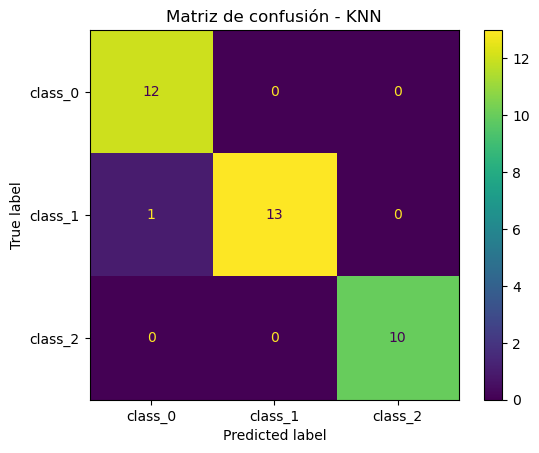

In [33]:
# Mostramos la matriz de confusión de manera gráfica
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot()
plt.title("Matriz de confusión - KNN")
plt.show()

### Classification report

El reporte de clasificación muestra las métricas de **precision**, **recall**, **f1-score** y **support** para cada clase.

In [34]:
# Generamos el reporte de clasificación
print(classification_report(y_test, prediccion))

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



## Conclusiones

En esta práctica se implementó el algoritmo K-Nearest Neighbors para clasificar los registros del dataset Wine. Primero se exploró el conjunto de datos y se comprobó que no contenía valores nulos ni registros duplicados, por lo que no fue necesario eliminar o reemplazar información.

La principal decisión de preparación fue estandarizar las variables con `StandardScaler`, porque KNN calcula distancias y las características del dataset tienen escalas diferentes. También se utilizó una división estratificada de 80 % para entrenamiento y 20 % para prueba, con el propósito de conservar la proporción de las tres clases.

El modelo se entrenó utilizando tres vecinos (`K = 3`). La exactitud, la matriz de confusión y el reporte de clasificación permitieron evaluar su desempeño. Los resultados muestran que KNN puede distinguir correctamente la mayoría de las clases del vino cuando los datos se preparan y escalan de manera adecuada.